# 1. Project Overview
![](https://www.investopedia.com/thmb/bOq9WGtsitVrH82eaR758iK0aOk=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc()/GettyImages-1132270894-516cf1c783a04c7c98b506d83b59711f.jpg)

The objective of this study is to model and forecast the exchange rate between the Euro (EUR) and the Algerian Dinar (DZD) using advanced Deep Learning architectures. Predicting currency fluctuations is a complex time-series task characterized by non-linear patterns and long-term dependencies that traditional statistical models often fail to capture.

To address this, we implement a comparative analysis of four DL architectures:

* Simple RNN.
* LSTM & GRU.
* Transformer.

# 2. Mathematical Formulation

We define our forecasting task as a mapping function $f$ that transforms a sequence of historical inputs into a sequence of future predictions.

Given a window of $w$ past observations, the model predicts the next $p$ values in the sequence:

$$(\hat{y}_1, \hat{y}_2, \dots, \hat{y}_p) = f(x_1, x_2, \dots, x_w)$$

# 3. Data Source and Data Description

For this analysis, we utilize the Forex Exchange Rates Since 2004 dataset available on Kaggle. This dataset provides daily historical exchange rates for various global currencies, updated frequently to reflect market changes.

* Dataset Link: [Forex Exchange Rates Since 2004 (Updated Daily)](https://www.kaggle.com/datasets/asaniczka/forex-exchange-rate-since-2004-updated-daily)
* Target Currency: Euro (EUR) to Algerian Dinar (DZD).

# 4. Importing Necessary Libraries

In [1]:
!pip install antropy
!pip install pymannkendall

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import antropy as ant
from pandas.plotting import lag_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import kendalltau
import pymannkendall as mk
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from scipy.stats import kruskal
from scipy.stats import friedmanchisquare
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dropout, Dense, MultiHeadAttention, LayerNormalization, Input, GlobalAveragePooling1D
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.callbacks import EarlyStopping
warnings.filterwarnings('ignore')

2025-12-24 00:54:02.521877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766537642.833746      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766537642.924016      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766537643.653794      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766537643.653853      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766537643.653856      55 computation_placer.cc:177] computation placer alr

# 5. Exploratory Data Analysis

We utilize the kagglehub library to programmatically download and load the dataset. This ensures the notebook remains reproducible and always uses the most recent version of the data.

In [3]:
file_path = "daily_forex_rates.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "asaniczka/forex-exchange-rate-since-2004-updated-daily",
  file_path,
)

df.head()

,currency,base_currency,currency_name,exchange_rate,date
0,ZWL,EUR,Zimbabwean Dollar,379.072921,2025-12-23
1,GHS,EUR,Ghanaian Cedi,13.404367,2025-12-23
2,HRK,EUR,Croatian Kuna,7.534610,2025-12-23
3,HNL,EUR,Honduran Lempira,30.924495,2025-12-23
4,HKD,EUR,Hong Kong Dollar,9.156135,2025-12-23


To facilitate a more intuitive exploration of the dataset, we restructure the DataFrame columns.

The restructured schema follows this order:

1. **base_currency:** The reference currency (e.g., USD or EUR).
2. **currency:** The target currency code (e.g., DZD).
3. **currency_name:** The full name of the target currency.
4. **exchange_rate:** The numerical value of the exchange.

In [4]:
# List the columns in the specific order you want
new_order = ['date', 'base_currency', 'currency', 'currency_name', 'exchange_rate']

# Apply the new order to the dataframe
df = df[new_order]

# Display the result
df.head()

,date,base_currency,currency,currency_name,exchange_rate
0,2025-12-23,EUR,ZWL,Zimbabwean Dollar,379.072921
1,2025-12-23,EUR,GHS,Ghanaian Cedi,13.404367
2,2025-12-23,EUR,HRK,Croatian Kuna,7.534610
3,2025-12-23,EUR,HNL,Honduran Lempira,30.924495
4,2025-12-23,EUR,HKD,Hong Kong Dollar,9.156135


In time-series forecasting, the integrity of the temporal sequence is paramount. Unlike standard classification tasks where data points are independent, currency exchange rates are autocorrelated, meaning a value at time t is highly dependent on values at $t−1$, $t−2$, ….

**Objective - Chronological Alignment:** We sort the dataset by the date column in ascending order to ensure that the "sliding window" moves correctly from historical data toward the future.

In [5]:
# Sort the dataframe so the oldest dates are at the top
df = df.sort_values(by='date', ascending=True)

# Reset the index so it starts at 0 for the earliest date
df = df.reset_index(drop=True)

# Show the first 5 records (should now be from 2004)
df.head()

,date,base_currency,currency,currency_name,exchange_rate
0,2004-08-30,EUR,AUD,Australian Dollar,1.7237
1,2004-08-31,EUR,AUD,Australian Dollar,1.7296
2,2004-08-31,EUR,JPY,Japanese Yen,132.8500
3,2004-08-31,EUR,CAD,Canadian Dollar,1.5967
4,2004-09-01,EUR,JPY,Japanese Yen,133.3500


The original dataset is a collection of various global currencies. To perform our specific analysis on the Algerian Dinar (DZD), we must isolate the relevant signals and transform the data into a univariate time series format.

**Objectives:**

* Currency Isolation: Filtering the dataset to exclude all other currency pairs, focusing exclusively on the DZD exchange rate.
* Dimensionality Reduction: Removing metadata columns (like currency_name and base_currency) that do not contribute to the predictive power of the deep learning models.


In [6]:
# 1. Filter the data to only show rows where currency is 'DZD'
dzd_df = df[df['currency'] == 'DZD'].copy()

# 2. Keep only the 'date' and 'exchange_rate' columns
dzd_df = dzd_df[['date', 'exchange_rate']]

# Set 'date' as the index and ensure it's in datetime format
dzd_df['date'] = pd.to_datetime(dzd_df['date'])
dzd_df = dzd_df.set_index('date')

# Display the result
dzd_df.head()

,exchange_rate
date,
2014-11-24,107.707
2014-11-25,107.078
2014-11-26,107.398
2014-11-27,107.055
2014-11-28,107.071


In [7]:
dzd_df.shape

(3114, 1)

Upon inspecting the filtered dataset for the Algerian Dinar (DZD), we observe a discrepancy between the global dataset start date and the available records for our target currency.

* Specific Start Date: While the general dataset encompasses data from 2004, the DZD exchange rate records specifically begin on November 24, 2014.
* Dataset Volume: The total number of observations available for training and testing is 3,114 entries.


In [8]:
dzd_df.isna().sum()

exchange_rate    0
dtype: int64

The analysis shows zero missing values. This indicates a high-quality dataset that does not require imputation (filling in gaps), allowing us to maintain the original market signals without introducing synthetic data.

**Distribution of Exchange Rates**

To understand the statistical properties of the DZD/EUR exchange rate, we visualize the data distribution using a histogram. This helps identify the frequency of specific price levels and the overall volatility of the currency.

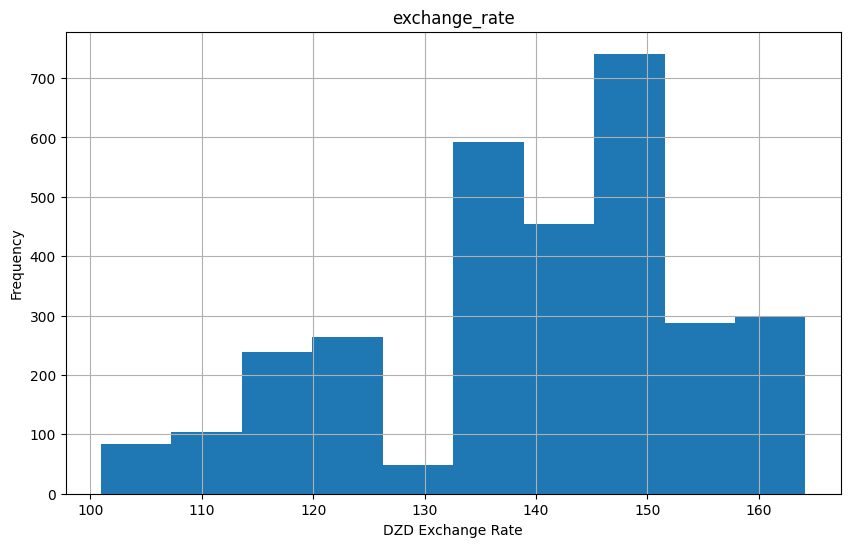

In [9]:
dzd_df.hist(figsize=(10, 6)) # Adjust figure size for better layout
plt.xlabel('DZD Exchange Rate')
plt.ylabel('Frequency')
plt.show()

**Key Observations from the Histogram:**

* Bimodal Distribution: The data exhibits two distinct peaks (clusters), primarily around the 135 and 150 marks. This suggests that the exchange rate has occupied two major "economic regimes" or stability levels during the 2014–2024 period.
  
* Range and Spread: The exchange rate fluctuates between approximately 100 and 165 DZD/EUR. The wide spread indicates significant depreciation of the Dinar over the observed decade.

  
* Non-Normality: The distribution is not Gaussian (normal). The presence of multiple peaks and a lack of symmetry confirm that traditional linear forecasting models may struggle, justifying the use of Non-linear Deep Learning models (LSTM, GRU, Transformers) that can adapt to complex data structures.


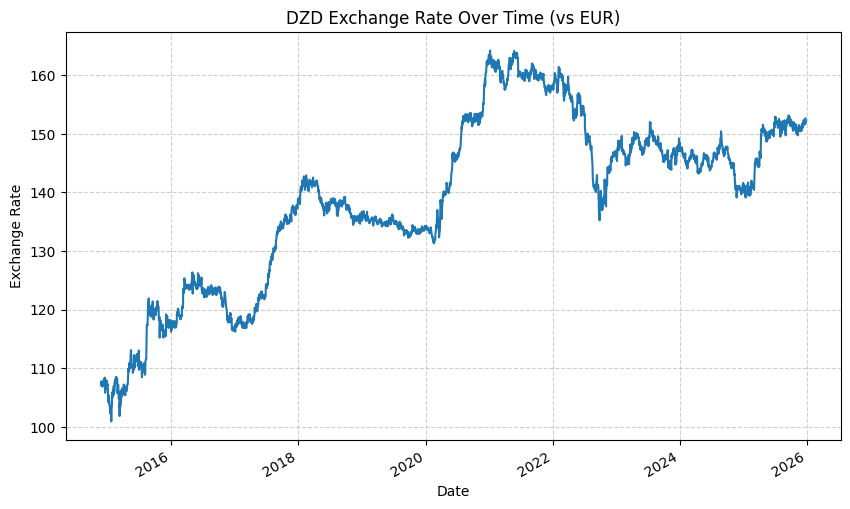

In [10]:
# 3. Create the line plot
plt.figure(figsize=(10, 6)) # Optional: adjust figure size

# Pandas plot method is a wrapper around Matplotlib's plot
dzd_df.plot(y='exchange_rate', legend=False, ax=plt.gca())

# 4. Add labels and title for clarity
plt.title('DZD Exchange Rate Over Time (vs EUR)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid

# 5. Display the plot
plt.show()

**Observation of Trends and Anomalies**
A closer inspection of the historical line plot reveals two critical characteristics of the Algerian Dinar's performance against the Euro:

* **Overall Upward Trend:** The series exhibits a persistent upward trend over the ten-year period. In the context of exchange rates, this indicates a long-term depreciation of the Dinar relative to the Euro.
  
* **The 2020-2021 Pandemic Peak:** We notice significant volatility and high peaks occurring around 2020-2021. These fluctuations correspond directly to the global economic disruptions caused by the COVID-19 pandemic, which impacted oil prices (a major driver for the Algerian economy) and disrupted international trade.

**Intra-Year Seasonal Analysis**

To further investigate the temporal dynamics, we decompose the exchange rate by year and month. This "Seasonal Plot" allows us to observe how the DZD/EUR rate fluctuates throughout a 12-month cycle and compare the relative price levels across different years.

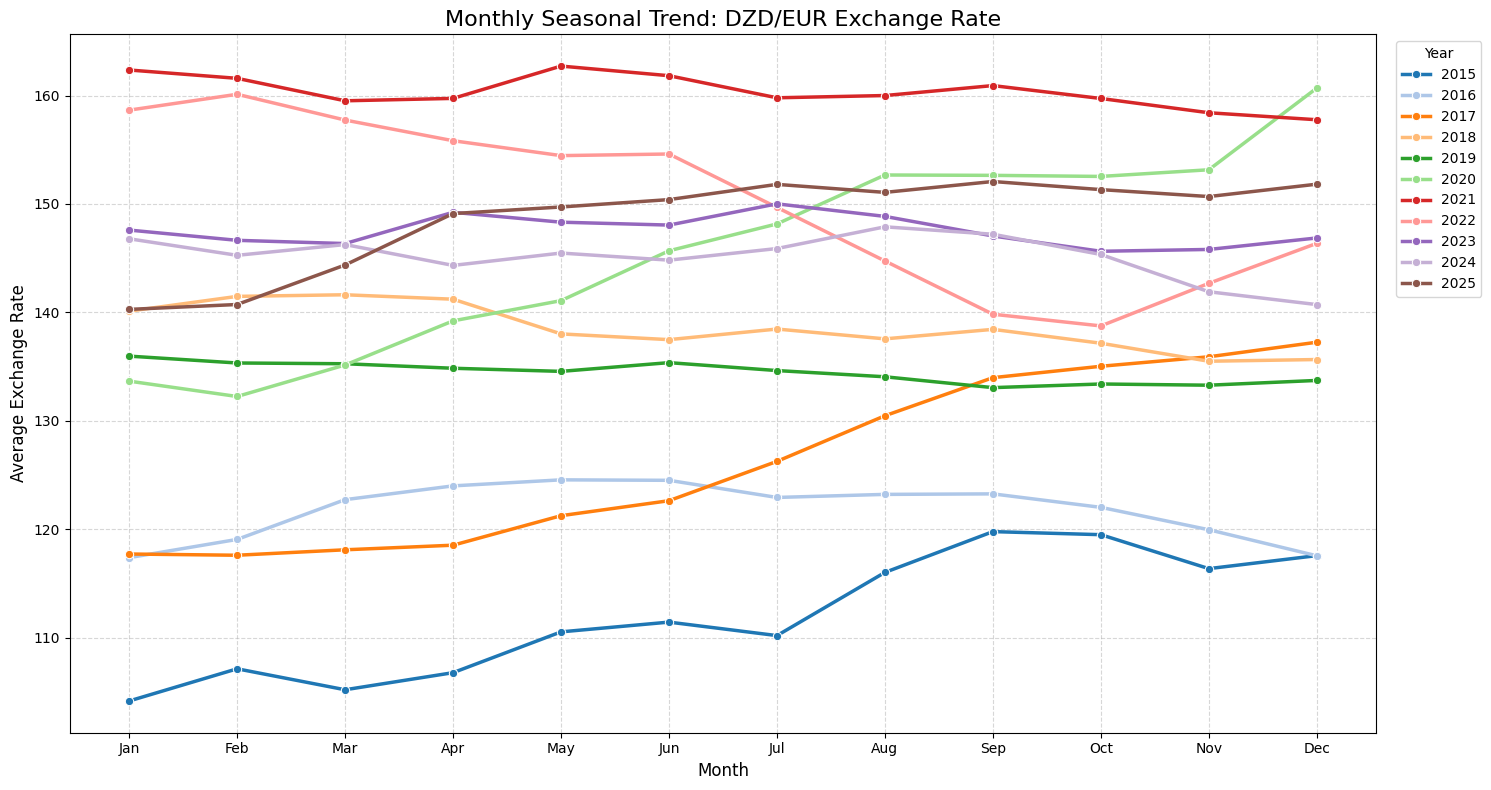

In [11]:
# Prepare the data
seasonal_df = dzd_df.copy()

# Aggregate to Monthly Average
monthly_avg = seasonal_df.resample('M').mean()
monthly_avg['Month'] = monthly_avg.index.month
monthly_avg['Year'] = monthly_avg.index.year

# Filter for a range (e.g., last 10 years for better visibility)
# Plotting 20+ years (since 2005) usually makes the chart too crowded
plot_df = monthly_avg[monthly_avg['Year'] >= 2015]

# Create the Seasonal Plot
plt.figure(figsize=(15, 8))

# Using 'tab10' or 'tab20' palette ensures high-contrast distinct colors
sns.lineplot(
    data=plot_df, 
    x='Month', 
    y='exchange_rate', 
    hue='Year', 
    palette='tab20',  # 'tab10' or 'viridis' work well
    linewidth=2.5,
    marker='o'        # Adds dots for each month to make it clearer
)

# Professional Styling
plt.title('Monthly Seasonal Trend: DZD/EUR Exchange Rate', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Exchange Rate', fontsize=12)

# Set X-axis labels to Month Names
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

plt.show()

**Key Observations:**
* **Confirmation of Long-Term Depreciation:** The vertical stacking of the lines clearly illustrates the upward trend. Each successive year (from the bottom blue line in 2015 to the higher lines in the 2020s) typically occupies a higher price bracket, confirming a steady decline in the Dinar's value.

* **Lack of Rigid Seasonality:** Unlike agricultural commodities or retail sales, the DZD/EUR rate does not show a single "fixed" seasonal peak (e.g., it doesn't always spike in December). This suggests that the exchange rate is influenced more by macroeconomic policy and global events than by recurring calendar-based cycles.
  
* **Significant Year-Specific Volatility:**
    1. **2021 (Dark Red Line):** Stays consistently at the top, showing the sustained pressure on the currency during the pandemic recovery.
       
    2. **2022 (Pink Line):** Shows a unique, sharp downward trend starting in the second half of the year, representing a rare period of Dinar appreciation or Euro weakness.

**Advanced Seasonal Distribution: Box and Violin Analysis**

To complete our Exploratory Data Analysis, we utilize Box and Violin plots to examine the statistical variance and price density of the DZD/EUR rate on a month-by-month basis (2015–2025).

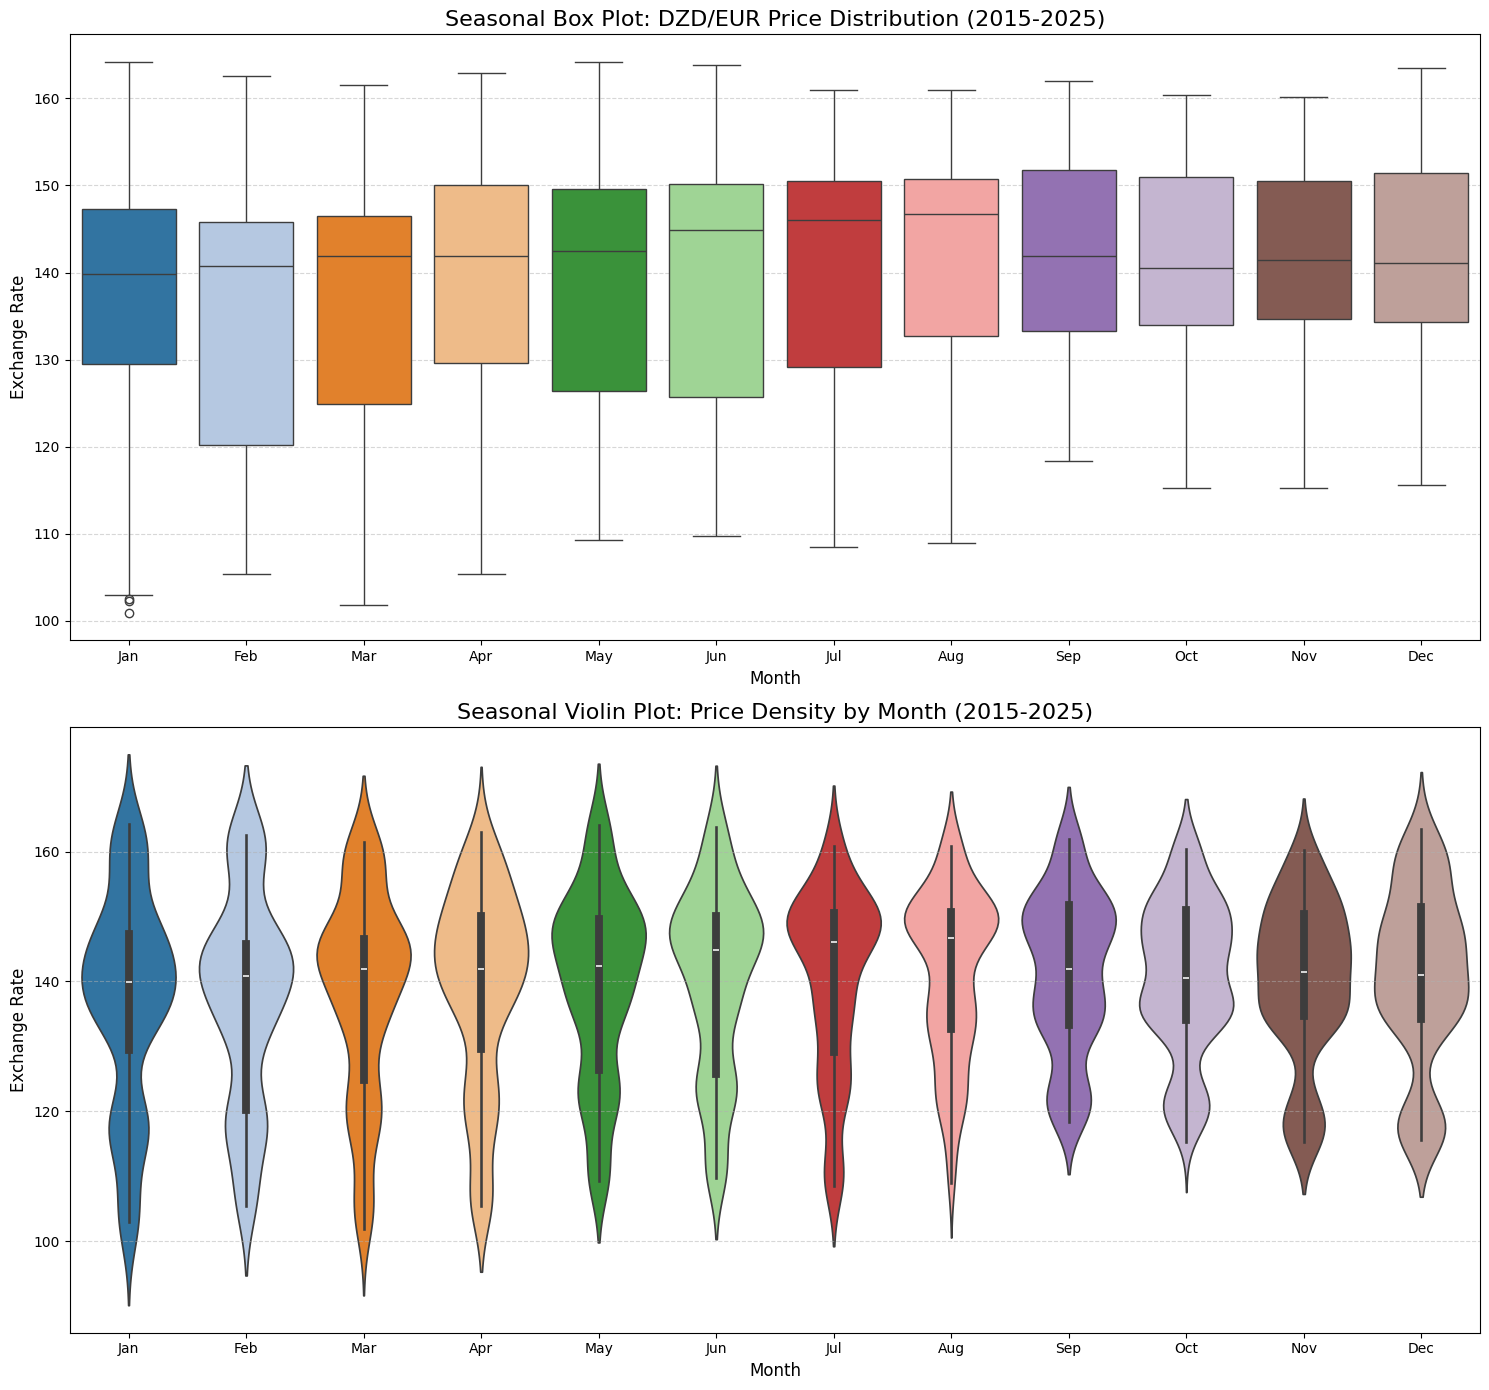

In [12]:
# 1. Prepare the daily data for the same range as your plot_df (2015+)
# We use the daily dzd_df to get the full distribution/spread of prices
plot_daily_df = dzd_df[dzd_df.index.year >= 2015].copy()
plot_daily_df['Month'] = plot_daily_df.index.month

# 2. Create the figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(15, 14))

# --- Plot 1: Seasonal Box Plot ---
# Shows medians and outliers (the "shocks")
sns.boxplot(ax=axes[0], data=plot_daily_df, x='Month', y='exchange_rate', palette='tab20')
axes[0].set_title('Seasonal Box Plot: DZD/EUR Price Distribution (2015-2025)', fontsize=16)

# --- Plot 2: Seasonal Violin Plot ---
# Shows the "density" or where the price spends the most time
sns.violinplot(ax=axes[1], data=plot_daily_df, x='Month', y='exchange_rate', palette='tab20')
axes[1].set_title('Seasonal Violin Plot: Price Density by Month (2015-2025)', fontsize=16)

# 3. Styling both plots
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for ax in axes:
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Exchange Rate', fontsize=12)
    ax.set_xticks(range(0, 12)) # Boxplot x-ticks start at 0
    ax.set_xticklabels(month_labels)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1. **Seasonal Box Plot:** The box plot summarizes the distribution of the exchange rate for each month across all years in the dataset.
        
    - **Low-Value Outliers:** The presence of several outliers below the lower whiskers (especially in the early months of the year) represents the lower exchange rate levels from the beginning of our sample period (2014–2016).
        
    - **Median Stability:** The median lines (the middle of the boxes) show a very gradual upward "creep," indicating that while there isn't a sharp seasonal spike, the Dinar has faced a persistent, long-term decline.

2. **Seasonal Violin Plot:** The violin plot provides a "Kernel Density Estimation," showing exactly where the exchange rate spent the most time.

    * **Regime Identification:** The "bulges" or fat sections in the violins indicate price levels where the exchange rate was most frequent. Many months show a wide density between 130 and 150,

**Seasonal Heatmap: Monthly Average Analysis**

The heatmap transforms our time-series data into a color-coded grid, where each cell represents the average exchange rate for a specific month and year. This visualization is particularly effective for identifying structural breaks and long-term shifts in the currency's value.

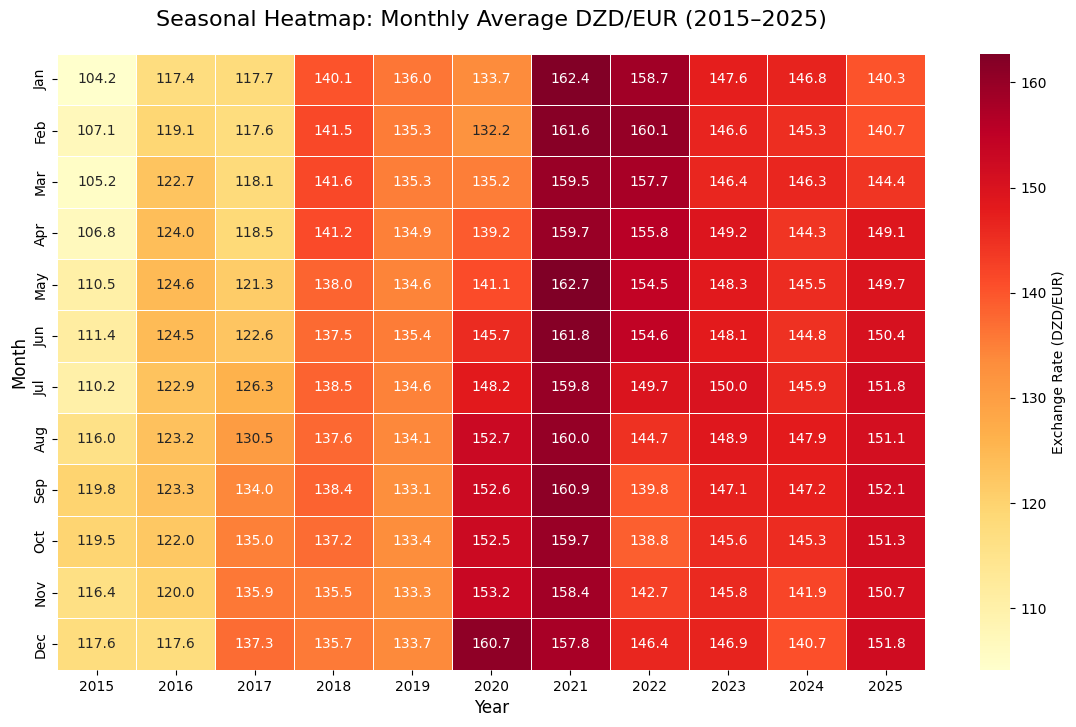

In [13]:
# 1. Pivot the data: Months as rows, Years as columns
# This creates the grid structure needed for the heatmap
heatmap_data = plot_df.pivot(index='Month', columns='Year', values='exchange_rate')

# 2. Map the index to Month Names for a professional look
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data.index = month_names

# 3. Create the Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,      # Shows the actual exchange rate in each cell
    fmt=".1f",       # Rounds the numbers to 1 decimal place
    cmap="YlOrRd",   # "Yellow-Orange-Red" palette (darker = higher rate)
    linewidths=.5,   # Adds thin lines between cells for clarity
    cbar_kws={'label': 'Exchange Rate (DZD/EUR)'}
)

# 4. Final Styling
plt.title('Seasonal Heatmap: Monthly Average DZD/EUR (2015–2025)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.show()

**Key Observations:**

* **Chronological Color Gradient:** There is a stark transition from light yellow (approx. 104 in 2015) to deep burgundy (approx. 162 in 2021). This visual "heat" map confirms the consistent, long-term depreciation of the Algerian Dinar against the Euro.

* **The 2020 Structural Break:** The map highlights 2020 as a critical turning point. Notice the rapid darkening of cells within that single year—starting at 133.7 in January and escalating to 160.7 by December. This represents an unprecedented period of intra-year volatility, likely driven by the global economic shock of the pandemic.

* **Post-2021 Stabilization:** From 2021 to 2025, the heatmap shows a "saturation" of dark red. While the rates remain high, the color intensity is more uniform compared to the rapid shifts seen between 2017 and 2020. This indicates that the currency has entered a new "high-rate regime."

**Autocorrelation Analysis: Determining the Optimal Window Size**

To build an effective forecasting model, we must determine how far back in time the model needs to "look" to find predictive signals. We use Lag Plots to visualize the relationship between the current exchange rate $y(t)$ and its past values $y(t−k)$, where $k$ represents the "lag."

**What is a "Lag"?**
In time-series analysis, a lag represents a fixed time delay.
* Lag 1 compares today's price with yesterday's price.
* Lag 7 compares today's price with the price from one week ago. By observing these scatter plots, we can see how much "memory" the exchange rate carries.

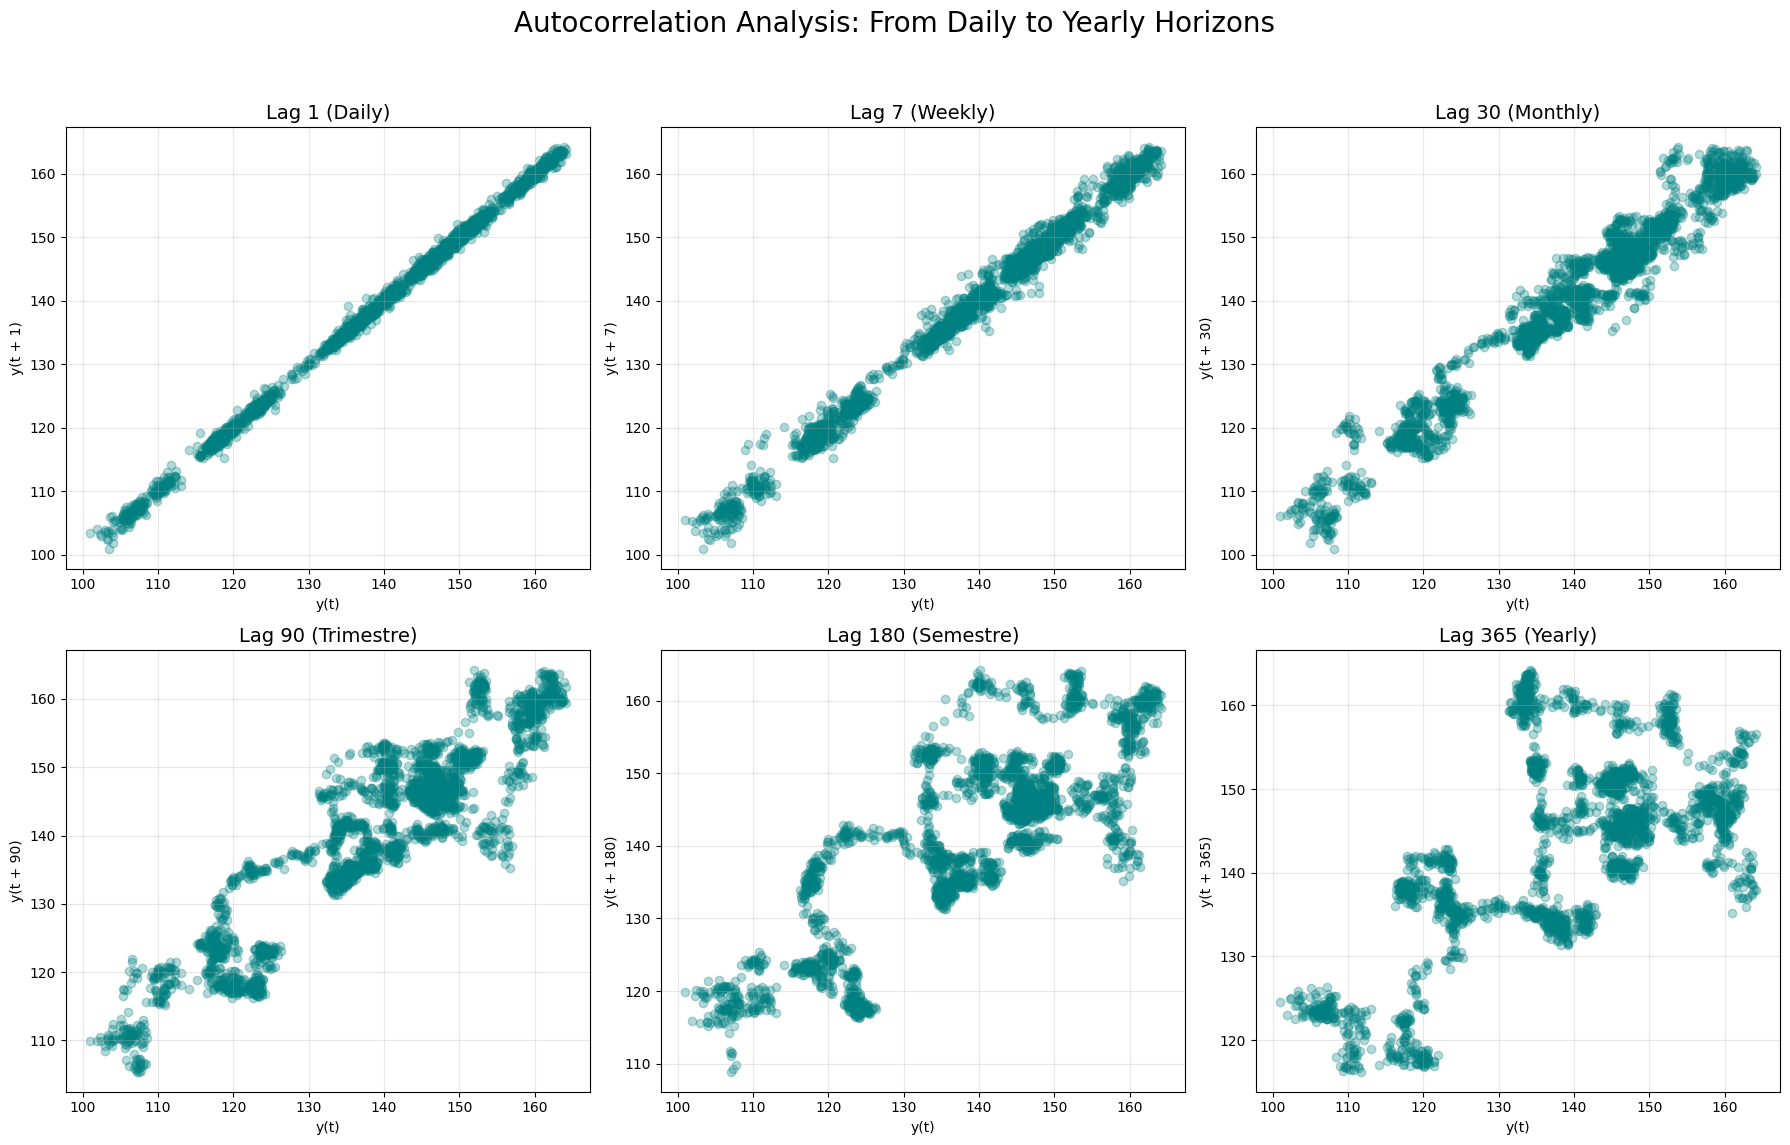

In [14]:
# 1. Define our lags (Daily, Weekly, Monthly, Quarterly, Semi-annually, Yearly)
lags = [1, 7, 30, 90, 180, 365]
titles = [
    'Lag 1 (Daily)', 'Lag 7 (Weekly)', 'Lag 30 (Monthly)', 
    'Lag 90 (Trimestre)', 'Lag 180 (Semestre)', 'Lag 365 (Yearly)'
]

# 2. Create a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Flatten to iterate easily with a single loop

# 3. Plot each lag
for i, lag in enumerate(lags):
    lag_plot(dzd_df['exchange_rate'], lag=lag, ax=axes[i], c='teal', alpha=0.3)
    axes[i].set_title(titles[i], fontsize=14)
    axes[i].set_xlabel('y(t)')
    axes[i].set_ylabel(f'y(t + {lag})')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Autocorrelation Analysis: From Daily to Yearly Horizons', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Plot Interpretations:**

* **Lag 1 (Daily) & Lag 7 (Weekly):** These plots show a very tight, linear alignment along the diagonal. This indicates an extremely high correlation. Today’s price is heavily influenced by the prices of the last 7 days, meaning the "near-past" is the strongest predictor for the "near-future."

* **Lag 30 (Monthly):** The linear relationship is still visible but starts to disperse. While a monthly correlation exists, it is significantly weaker and more prone to noise than the weekly data.

* **Lag 90, 180, & 365 (Long-Term):** For horizons of 3 months or more, the linear pattern breaks down almost entirely, forming chaotic clusters. This suggests that price movements from several months ago have no significant predictive power over current prices.

**Conclusion and Modeling Strategy**
The analysis of these lags leads to several critical decisions for our Deep Learning architectures:
* **Short-Term Dependency:** The previous day and the previous 7 days are the most influential time steps.
  
* **Sequence Length (seq_length):** Based on the strong linear retention in the Lag 7 plot, we will adopt a 7-day window size $(w=7)$. This captures the most reliable signal while avoiding the "diluted" or noisy signals found in longer lags.

**Statistical Correlation Analysis: ACF and PACF**

* **ACF (Autocorrelation Function):** Measures the correlation between a value and a lagged version of itself while considering the cumulative effects of all intermediate values.

* **PACF (Partial Autocorrelation Function):** Measures the direct correlation between two points in time. It isolates the specific relationship between today’s price and a price $k$ days ago by mathematically removing the influence of the days in between.

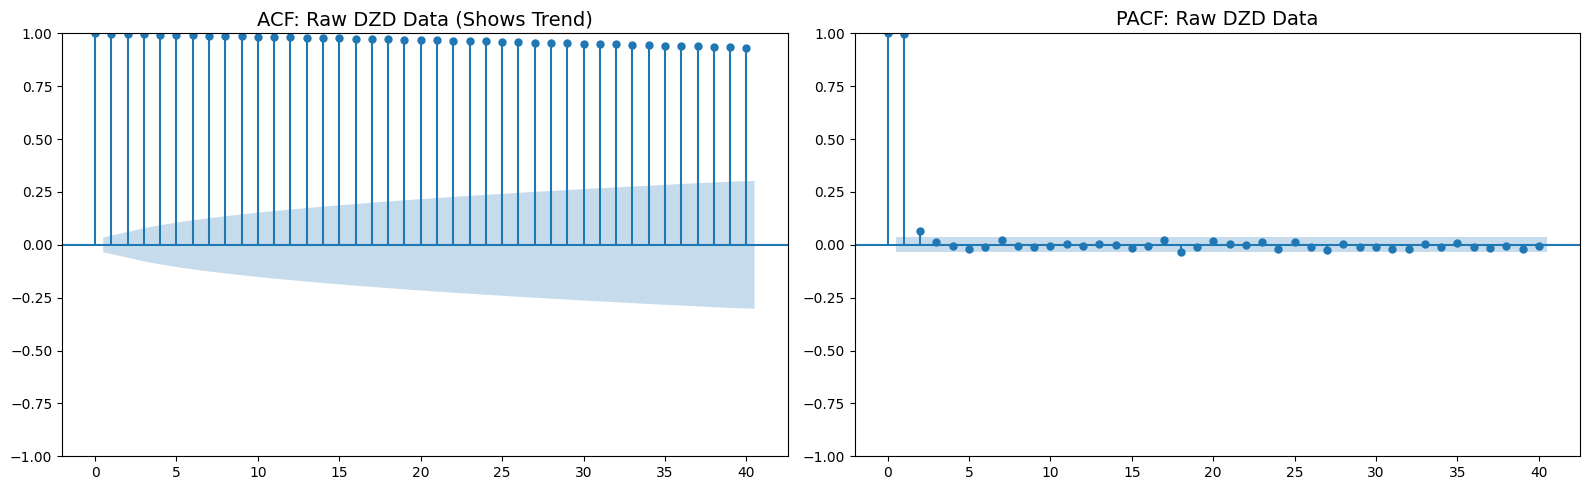

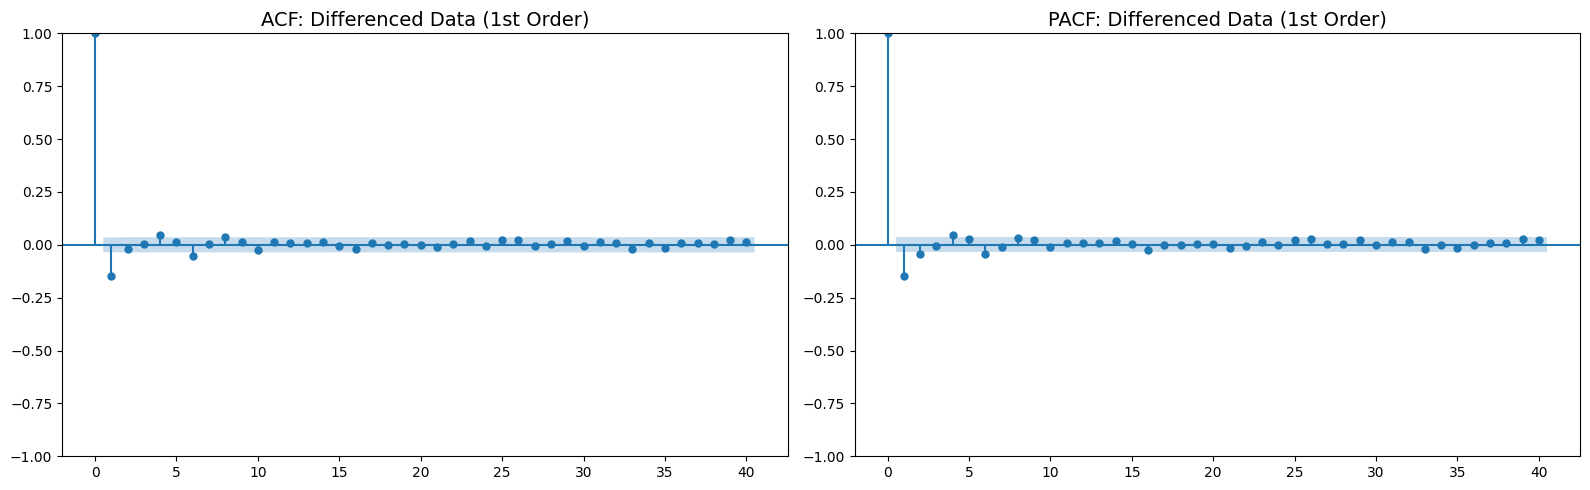

In [15]:
# 1. Create a figure for Raw Data
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF on Raw Data
plot_acf(dzd_df['exchange_rate'], lags=40, ax=axes[0])
axes[0].set_title('ACF: Raw DZD Data (Shows Trend)', fontsize=14)

# PACF on Raw Data
plot_pacf(dzd_df['exchange_rate'], lags=40, ax=axes[1])
axes[1].set_title('PACF: Raw DZD Data', fontsize=14)

plt.tight_layout()
plt.show()

# 2. Create a figure for Differenced Data (Daily Returns)
# This is usually what we use to identify model orders
dzd_diff = dzd_df['exchange_rate'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF on Differenced Data
plot_acf(dzd_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF: Differenced Data (1st Order)', fontsize=14)

# PACF on Differenced Data
plot_pacf(dzd_diff, lags=40, ax=axes[1])
axes[1].set_title('PACF: Differenced Data (1st Order)', fontsize=14)

plt.tight_layout()
plt.show()

**1. Interpretation of the Raw Plots**

* **ACF - The Trend Signal:** The ACF plot shows values staying extremely high (near 1.0) across all 40 lags with a very slow decay. This is a classic signature of Non-Stationarity. It confirms that the raw price is dominated by a strong upward trend, meaning today's price is heavily "carried over" from yesterday.
    
* **PACF - The Direct Influence:** The PACF shows a massive spike at Lag 1 (nearly 1.0) and virtually no significant correlation afterward. This tells us that in the raw data, the most "direct" predictor of today's price is simply yesterday's price.

**2. Interpretation of the Differenced Plots**

* **Significance of Lags:** In both the ACF and PACF of the differenced data, almost all bars after the first few lags fall within the blue shaded region (the 95% confidence interval). This indicates that historical data points beyond this point offer no additional predictive signal, meaning that increasing the window size further would have a negligible impact on the model's predictive power.

* **The Dominance of the Near-Past:** We see significant spikes only in the very early lags (Lags 1 through 7). This proves that the most influential factors for predicting tomorrow's change are the events of the previous week.

**Coefficient of Variation (CV): Assessing Predictability**

The CV is calculated as the ratio of the Standard Deviation $(σ)$ to the Mean $(μ)$:

$$\mathrm{CV} = \frac{\sigma}{\mu}$$

In statistical modeling, a lower CV value indicates higher predictability. It suggests that the data points are clustered more closely around the mean, meaning the series is more stable and less prone to extreme, erratic outliers that could confuse the model.

In [16]:
overall_mean = dzd_df['exchange_rate'].mean()
overall_std = dzd_df['exchange_rate'].std()
overall_cv = (overall_std / overall_mean)

print(f"--- Overall Dataset Metrics ---")
print(f"Mean: {overall_mean:.2f}")
print(f"Std Dev: {overall_std:.2f}")
print(f"Overall CV: {overall_cv:.4f}")

--- Overall Dataset Metrics ---
Mean: 139.38
Std Dev: 14.36
Overall CV: 0.1030


**Our Result:** A CV of 0.1030 (10.3%) indicates that the exchange rate is relatively stable. This is an ideal range for Deep Learning, as it provides enough variance for the model to learn "movement" without being so chaotic that the signal is lost in the noise.

**Time Series Decomposition: Structural Analysis**

* **Original Data:** The actual exchange rate values as they were observed.
* **Trend:** The overall direction of the data over time (going up, going down, or staying stable).
* **Seasonality:** Regular patterns that repeat over a fixed period, such as monthly or yearly cycles.
* **Residuals (Noise):** The remaining random variations after removing the trend and seasonal patterns. These are unexpected changes or shocks that the model cannot explain.

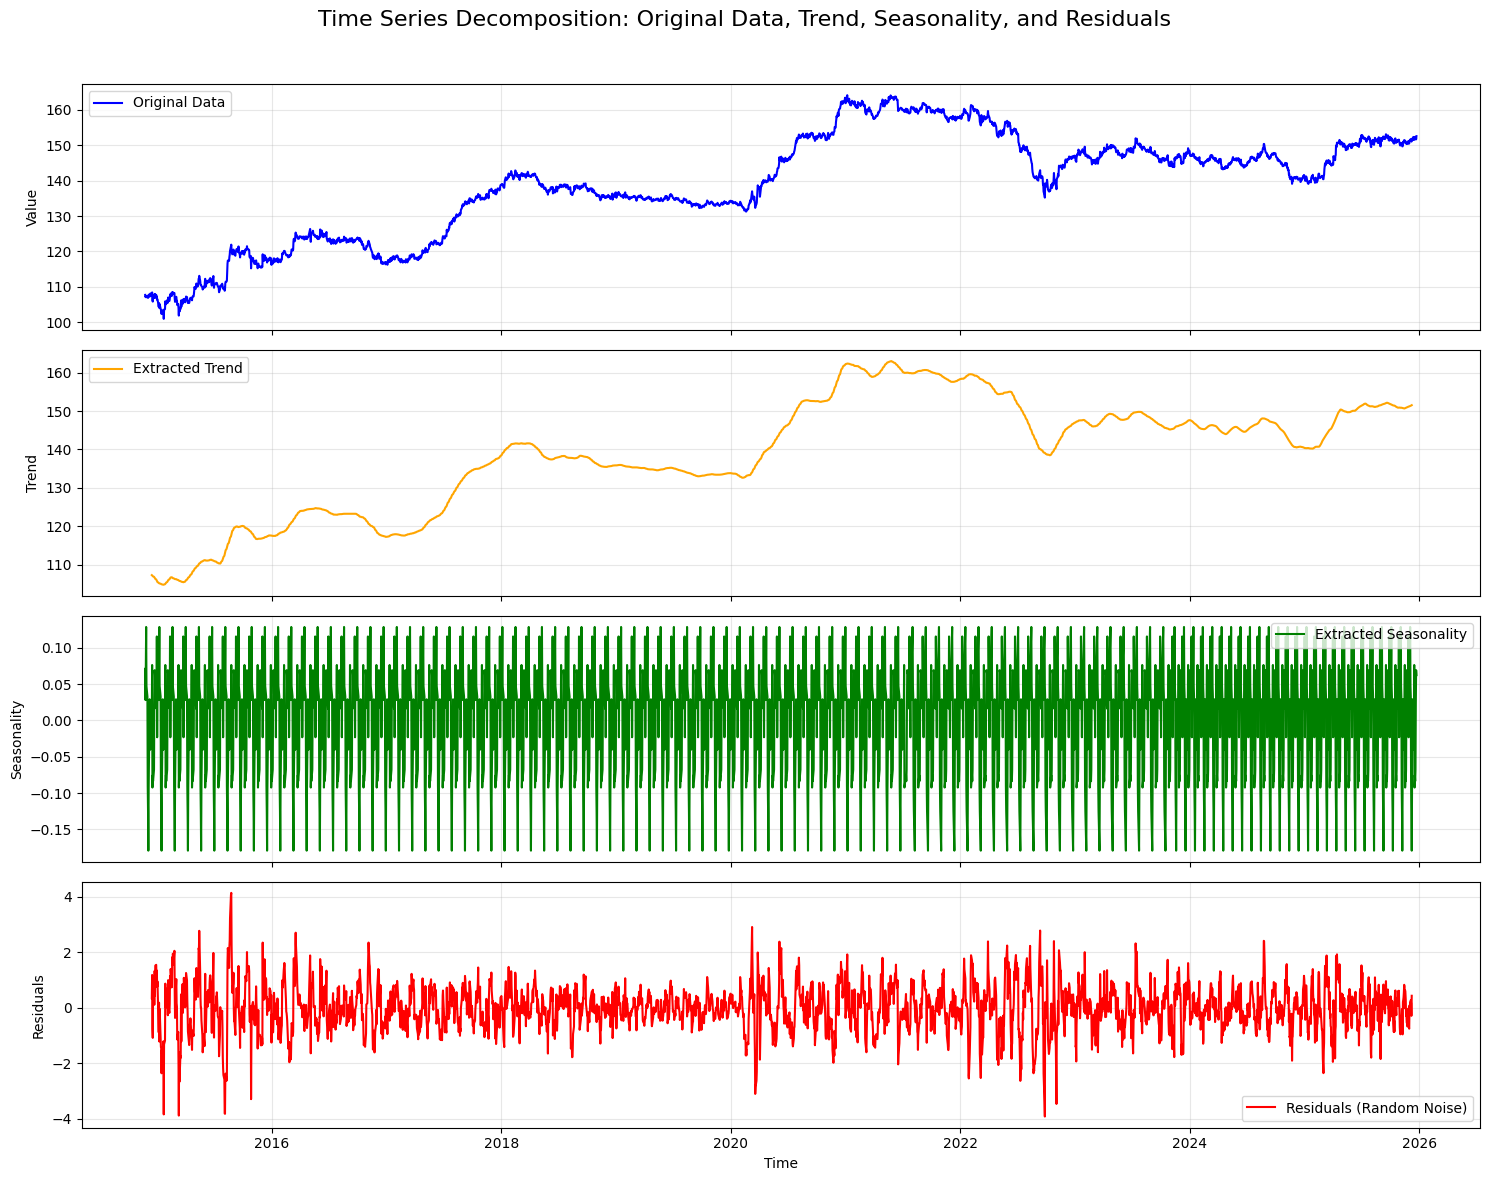

In [17]:
# 1. Perform the decomposition
# We use period=30 assuming you want to check for monthly patterns
# Use model='additive' if the seasonal fluctuations are constant over time
result = seasonal_decompose(dzd_df['exchange_rate'], model='additive', period=30)

# 2. Create the 4-panel custom plot
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Panel 1: Original Data
axes[0].plot(result.observed, color='blue', label='Original Data')
axes[0].set_ylabel('Value')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Panel 2: Trend
axes[1].plot(result.trend, color='orange', label='Extracted Trend')
axes[1].set_ylabel('Trend')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# Panel 3: Seasonality
axes[2].plot(result.seasonal, color='green', label='Extracted Seasonality')
axes[2].set_ylabel('Seasonality')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

# Panel 4: Residuals (The Noise)
axes[3].plot(result.resid, color='red', label='Residuals (Random Noise)')
axes[3].set_ylabel('Residuals')
axes[3].set_xlabel('Time')
axes[3].legend(loc='lower right')
axes[3].grid(True, alpha=0.3)

# Add the main title
plt.suptitle('Time Series Decomposition: Original Data, Trend, Seasonality, and Residuals', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

* **Dominant Trend:** The extracted trend shows a strong, non-linear upward movement. Since this trend closely follows the overall pattern of the original exchange rate, it indicates that long-term economic factors are the main force driving the value of the Algerian Dinar.

* **Negligible Seasonality:** A close look at the y-axis of the extracted seasonal component (ranging from +0.10 to −0.15) shows that, compared to the actual exchange rate values (around 140), these seasonal fluctuations are mathematically insignificant. This confirms our earlier finding that the Algerian Dinar does not follow a strict calendar-based cycle; instead, its movements are mainly driven by external factors.

* **Volatility in Residuals:** The Residuals plot shows significant "spikes," especially around the 2020-2021 period. Because these spikes are large and occur at a specific time, they represent external shocks (like the COVID-19 pandemic) that a simple seasonal model could never predict.

**Complexity Analysis: Entropy-Based Forecastability**

To quantify the complexity of the DZD/EUR exchange rate, we utilize Approximate Entropy (ApEn) and Sample Entropy (SampEn). These metrics measure the "randomness" or "irregularity" of a time series.

**Understanding Entropy**

* **High Entropy:** Indicates a chaotic, irregular series (like white noise) that is extremely difficult to predict.
* **Low Entropy:** Indicates a highly ordered series with repeating patterns and strong regularities.

In [18]:
# 1. Prepare the data (ensure it's a numpy array)
data = dzd_df['exchange_rate'].values

# 2. Calculate Approximate Entropy (ApEn)
# m: embedding dimension (usually 2 for short/medium series)
# r: tolerance (standard is 0.2 * std of the data)
apen = ant.app_entropy(data, order=2)

# 3. Calculate Sample Entropy (SampEn)
# More consistent and better for identifying patterns
sampen = ant.sample_entropy(data, order=2)

print(f"--- Entropy-Based Forecastability ---")
print(f"Approximate Entropy (ApEn): {apen:.4f}")
print(f"Sample Entropy (SampEn): {sampen:.4f}")

--- Entropy-Based Forecastability ---
Approximate Entropy (ApEn): 0.0764
Sample Entropy (SampEn): 0.0681


The results are exceptionally low, suggesting that the Algerian Dinar time series is highly regular and contains significant predictable structure. It is far from behaving like a random walk.

**Kaboudan Metric: Forecastability Validation**

The Kaboudan Metric is a sophisticated test used to determine if a time series is a "Random Walk" or if it contains a deterministic structure that a model can learn.

The Formula:

$$Kaboudan = 1-\frac{SSE_{original}}{SSE_{shuffled}}$$

* **$SSE_{original}$ (Original):** The error when trying to predict the next value using the current one in the real sequence.
* **$SSE_{shuffled}$ (Shuffled):** The error when trying to do the same after the time-order has been destroyed by shuffling.

* **Result Significance:** A value close to 1.0 indicates that the series is highly structured and contains a very strong "signal." Conversely, a value near 0.0 would suggest the data is purely random (like white noise).

In [19]:
def calculate_kaboudan(series):
    # 1. Prepare Original Series (SSE_n)
    # y_true is the actual price, y_pred is the price from one day before
    y_true = series[1:]
    y_pred_original = series[:-1]
    sse_n = np.sum((y_true - y_pred_original)**2)

    # 2. Create Shuffled Series (SSE_s)
    # We shuffle the data to break the "Temporal Structure" 
    shuffled_series = series.copy()
    np.random.shuffle(shuffled_series)
    
    # Forecast on shuffled data
    y_true_s = shuffled_series[1:]
    y_pred_shuffled = shuffled_series[:-1]
    sse_s = np.sum((y_true_s - y_pred_shuffled)**2)

    # 3. Compute Kaboudan Metric: 1 - (SSE_n / SSE_s)
    kaboudan_metric = 1 - (sse_n / sse_s)
    
    return kaboudan_metric, sse_n, sse_s

# Run the calculation on your exchange rate column
data_values = dzd_df['exchange_rate'].values
k_metric, sse_n, sse_s = calculate_kaboudan(data_values)

print(f"--- Kaboudan Metric Results ---")
print(f"SSE (Original Data): {sse_n:.2f}")
print(f"SSE (Shuffled Data): {sse_s:.2f}")
print(f"Kaboudan Metric: {k_metric:.4f}")

--- Kaboudan Metric Results ---
SSE (Original Data): 1103.55
SSE (Shuffled Data): 1306796.18
Kaboudan Metric: 0.9992


**Interpretation of Results:**
* **Kaboudan Metric:** 0.9991
* The EURO to DZD exchange rate series is highly structured and predictable. It is far from a random walk, meaning the model can reliably exploit historical data to forecast future values. The very high Kaboudan value confirms that the series has strong temporal dependencies and is not driven by random noise.

**Trend Detection: Kendall’s Tau and Mann-Kendall Validation**

To formally prove the trend we’ve observed visually, we apply two robust statistical tests: Kendall’s Tau and the Mann-Kendall (MK) Test. Unlike standard correlation, these tests are "non-parametric," meaning they are not fooled by outliers or the specific distribution of the data.

In [20]:
# 1. Prepare data (Values and a numerical time index)
values = dzd_df['exchange_rate'].values
time_index = np.arange(len(values))

# 2. Calculate Kendall’s Tau
# Measures the strength of the monotonic relationship between time and the rate
tau, p_value_tau = kendalltau(time_index, values)

# 3. Perform Mann-Kendall (MK) Test
# H0: No trend present; H1: Trend exists
mk_result = mk.original_test(values)

print(f"--- Trend Detection Results ---")
print(f"Kendall’s Tau: {tau:.4f}")
print(f"Tau P-Value: {p_value_tau:.4e}")
print(f"\nMann-Kendall Test Result: {mk_result.trend}")
print(f"MK P-Value: {mk_result.p:.4e}")
print(f"MK Slope (Theil-Sen): {mk_result.slope:.6f}")

--- Trend Detection Results ---
Kendall’s Tau: 0.5177
Tau P-Value: 0.0000e+00

Mann-Kendall Test Result: increasing
MK P-Value: 0.0000e+00
MK Slope (Theil-Sen): 0.011408


**Metric Definitions**

* **Kendall’s Tau (0.5176):** This measures the strength of the monotonic relationship between time and the exchange rate. A value of 0.5176 indicates a moderate-to-strong positive relationship, meaning that as time progresses, the exchange rate consistently moves to higher levels.

* **Mann-Kendall (MK) Test:** This is a formal hypothesis test where the null hypothesis $(H_0)$ is that there is no trend.

    * **Result: "increasing"** — The test definitively identifies a persistent upward trajectory.
    
    * **P-Value: 0.0000 —** Since the p-value is effectively zero, we reject the null hypothesis with near-total certainty.

**Theil-Sen Slope (0.0114):** This represents the "median slope" of the trend. It tells us that, on average, the EUR/DZD rate has been increasing by approximately 0.0114 units per day over the last decade.

**Stationarity Testing: Augmented Dickey-Fuller (ADF)**

Stationarity: A time series is "stationary" if its statistical properties—such as mean, variance, and autocorrelation—remain constant over time. Stationary data is much easier to predict because the "rules" governing the data don't change.

In [21]:
# 1. Run the ADF Test on the Raw Data
result = adfuller(dzd_df['exchange_rate'])

print(f"--- ADF Test Results---")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

# 2. Interpretation Logic
if result[1] < 0.05:
    print("\nResult: p-value < 0.05. Reject H0. The series is STATIONARY.")
else:
    print("\nResult: p-value >= 0.05. Fail to reject H0. The series is NON-STATIONARY (Unit Root exists).")

--- ADF Test Results---
ADF Statistic: -2.0800
p-value: 0.2526

Result: p-value >= 0.05. Fail to reject H0. The series is NON-STATIONARY (Unit Root exists).


**Interpretation of Results**
* **ADF Statistic (-2.1001):** This value is compared against critical values. Typically, the more negative this statistic is, the more likely the data is stationary.
* **P-Value:** Since 0.2445 > 0.05, we fail to reject the Null Hypothesis $(H_0)$.
* **Conclusion:** The test confirms that a Unit Root exists and the DZD/EUR exchange rate is Non-Stationary.

**Heteroscedasticity Analysis: White Test**

**Heteroscedasticity (Observed):** The variance is not constant. This means there are "sub-periods" in the data where the exchange rate is much more volatile (large, erratic jumps) and other periods where it is relatively stable (flat or smooth movements).

In [22]:
# 1. Prepare the data for a simple regression (Rate vs Time)
X = np.arange(len(dzd_df)).reshape(-1, 1)
X = sm.add_constant(X)  # Adds an intercept
y = dzd_df['exchange_rate'].values

# 2. Fit the OLS model to get residuals
model = sm.OLS(y, X).fit()
residuals = model.resid

# 3. Perform the White Test
# The test requires the residuals and the predictors (X)
white_test = het_white(residuals, X)

labels = ['Test Statistic', 'Test p-value', 'F-Statistic', 'F-Test p-value']
results = dict(zip(labels, white_test))

print(f"--- White Test Results ---")
for key, value in results.items():
    print(f"{key}: {value:.4e}")

# 4. Interpretation
if results['Test p-value'] < 0.05:
    print("\nResult: p-value < 0.05. Reject H0. HETEROSCEDASTICITY detected.")
else:
    print("\nResult: p-value >= 0.05. Fail to reject H0. HOMOSCEDASTICITY (Constant Variance) detected.")

--- White Test Results ---
Test Statistic: 6.8290e+01
Test p-value: 1.4829e-15
F-Statistic: 3.4877e+01
F-Test p-value: 1.0485e-15

Result: p-value < 0.05. Reject H0. HETEROSCEDASTICITY detected.


* Decision: Since both p-values are significantly lower than 0.05, we Reject the Null Hypothesis $(H_0)$.
  
* The test confirms that heteroscedasticity exists in the series.

**Non-Parametric Seasonal Validation: Kruskal-Wallis & Friedman Tests**

In [23]:
# 1. Prepare data (using daily changes to avoid trend bias)
dzd_df['returns'] = dzd_df['exchange_rate'].diff()
df_clean = dzd_df.dropna()

# 2. Group returns by month
monthly_groups = [df_clean[df_clean.index.month == i]['returns'] for i in range(1, 13)]

# 3. Perform Kruskal-Wallis
stat_kw, p_kw = kruskal(*monthly_groups)

print(f"--- Kruskal-Wallis Test (Monthly Groups) ---")
print(f"Statistics: {stat_kw:.4f}, p-value: {p_kw:.4f}")

--- Kruskal-Wallis Test (Monthly Groups) ---
Statistics: 11.1652, p-value: 0.4295


In [24]:
# 1. Calculate average monthly return per year
pivot_df = df_clean.pivot_table(index=df_clean.index.year, 
                               columns=df_clean.index.month, 
                               values='returns', 
                               aggfunc='mean').dropna()

# 2. Perform Friedman Test
stat_f, p_f = friedmanchisquare(*(pivot_df[m] for m in range(1, 13)))

print(f"\n--- Friedman Test (Monthly Consistency across Years) ---")
print(f"Statistics: {stat_f:.4f}, p-value: {p_f:.4f}")


--- Friedman Test (Monthly Consistency across Years) ---
Statistics: 14.7063, p-value: 0.1963


* **Kruskal-Wallis Result (p-value: 0.4567):** Since the p-value is significantly higher than the 0.05 threshold, we fail to reject the null hypothesis. This means there is no statistically significant difference in how the exchange rate moves from one month to another.

* **Friedman Test Result (p-value: 0.2265):** Again, the p-value is greater than 0.05. This indicates that there is no consistent "monthly ranking" across the years. A month that shows high growth in 2018 may show a decline in 2022.

* **Conclusion of the analysis:** These results provide the final mathematical proof that there is no reliable seasonality in the DZD/EUR exchange rate. Unlike some commodities or stocks that might have "holiday effects" or "quarterly cycles," the Algerian Dinar's movements are independent of the calendar. 

**Non-Linear Feature Selection: Mutual Information & Elbow Detection**

Mutual Information: Measures the "amount of information" obtained about the current price $(x_t)$ by observing a past price $(x_t−k)$. Unlike correlation, MI can capture complex, non-linear patterns that a standard line might miss.

In [25]:
def mutual_information_lags(series, max_lag=100):
    """
    Compute mutual information between x_t and x_{t-k}
    """
    series = np.asarray(series)
    mi_values = []

    for lag in range(1, max_lag + 1):
        x = series[:-lag].reshape(-1, 1)
        y = series[lag:]
        mi = mutual_info_regression(x, y, random_state=0)
        mi_values.append(mi[0])

    return np.array(mi_values)

**The Elbow Method:** This geometric technique identifies the "point of diminishing returns." It finds the specific lag where the information gain drops off sharply and begins to level out.

In [26]:
def find_elbow_point(lags, mi_values):
    # 1. Define the start (P1) and end (P2) points of the secant line
    x1, y1 = lags[0], mi_values[0]
    x2, y2 = lags[-1], mi_values[-1]
    
    # 2. Calculate distances using the 2D point-to-line formula:
    # distance = |(y2-y1)x0 - (x2-x1)y0 + x2y1 - y2x1| / sqrt((y2-y1)^2 + (x2-x1)^2)
    numerator = np.abs((y2 - y1) * lags - (x2 - x1) * mi_values + x2 * y1 - y2 * x1)
    denominator = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
    distances = numerator / denominator
    
    # 3. The elbow is the point with the maximum distance
    elbow_idx = np.argmax(distances)
    return lags[elbow_idx]

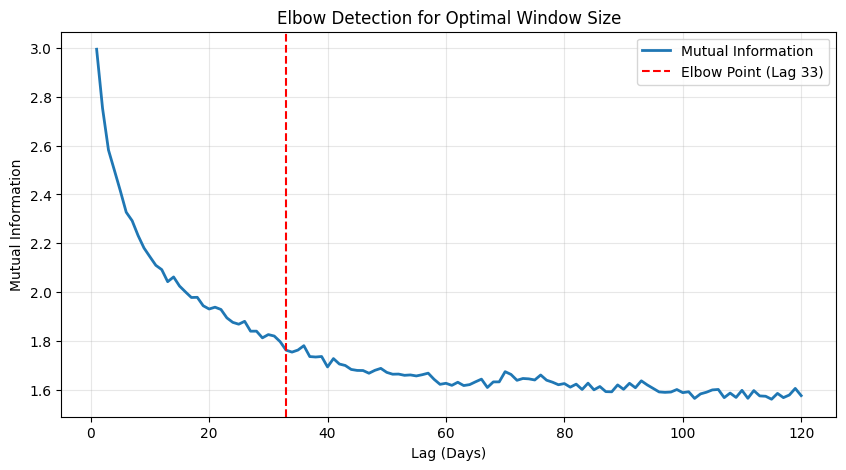

The mathematically detected elbow is at Lag: 33


In [27]:
# --- Integrated Plotting Code ---
max_lag = 120
mi_scores = mutual_information_lags(dzd_df['exchange_rate'], max_lag)
lags = np.arange(1, max_lag + 1)

# Find the elbow
elbow_lag = find_elbow_point(lags, mi_scores)

plt.figure(figsize=(10, 5))
plt.plot(lags, mi_scores, label='Mutual Information', color='tab:blue', linewidth=2)
plt.axvline(x=elbow_lag, color='red', linestyle='--', label=f'Elbow Point (Lag {elbow_lag})')

# Visual styling
plt.xlabel("Lag (Days)")
plt.ylabel("Mutual Information")
plt.title("Elbow Detection for Optimal Window Size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"The mathematically detected elbow is at Lag: {elbow_lag}")

* **Information Decay:** The plot shows a sharp initial drop in Mutual Information. This confirms that the most recent days hold the vast majority of predictive power.

* **Significance:** This suggests that the "informative memory" of the DZD/EUR exchange rate spans approximately one trading month (roughly 30–33 days). Beyond this 33-day window, the information curve flattens significantly, meaning that adding 40, 50, or 100 days of history provides almost no new useful information to the model.

* This result provides a "data-driven" alternative to our earlier 7-day window. While the strongest signal is in the first week, this test proves that there is still a meaningful non-linear signal available up to day 33. This gives you two valid options for your model architecture:
    * **A 7-day window:** Focused on the highest-intensity signal (Efficiency).
    * **A 33-day window:** Capturing the full "information horizon" before the data becomes redundant (Completeness).

# 6.  **Data Transformation: Differencing and Scaling**

**First-Order Differencing**

As proven by our earlier ADF Test, the raw data is non-stationary. To fix this, we calculate the difference between consecutive days. This forces the model to learn the "momentum" of the market rather than just the absolute price level.

**Mathematical Formulation:** The differenced value at time $t$ $(\Delta y_t)$ is calculated as:

$$\Delta y_t = y_t - y_{t-1}$$

**Chronological Train-Test Split (80/20)**

Unlike standard machine learning, time-series data cannot be shuffled. We must maintain the temporal order.

* **Training Set (80%):** It will be used for the model to learn historical patterns.

* **Test Set (20%):** The remaining days are reserved to evaluate how the model performs on "unseen" future data.

**Min-Max Scaling (Range: -1 to 1)**

* Since we are now working with differenced data, our values represent daily fluctuations. Because the exchange rate can go down as well as up, many of these differences are negative.

* Why [-1, 1]? Standard scaling (0 to 1) is used for absolute values. By using the range [−1,1], we preserve the mathematical significance of the zero-point. A value of -1 represents the maximum historical decrease, 0 represents no change, and 1 represents the maximum historical increase.

**Sequence Generation: The Sliding Window Logic**

* To feed the data into a neural network, we must convert a single column of numbers into a supervised learning problem using a Sliding Window.

**The "Many-to-Many" Mapping**

* We create pairs of inputs $(X)$ and targets $(y)$ by sliding a window across the timeline:
    * **Sequence 1:** Input $[x_1, x_2, ..., x_w] \rightarrow [y_1, ... , y_o] $
    * **Sequence 2:** Input $[x_2, x_3, ..., x_{w+1}] \rightarrow [y_2, ..., y_{o+1}] $
    * **Sequence 3:** Input $[x_3, x_4, ..., x_{w+2}] \rightarrow [y_3, ..., y_{o+2}] $

**Defining the Temporal Horizon: Input and Output Windows**

* Based on the ACF, PACF, mutual information, and lag plot analyses, we selected an input window size of 7.

* We set the output window to 1 to address a specific high-value business need: daily liquidity planning. For Algerian businesses importing goods from the EU, anticipating tomorrow’s exchange rate is crucial for deciding whether to execute a bank transfer today or wait 24 hours in order to reduce currency conversion costs.

* Feel free to adjust these window parameters according to your specific preferences or experimental requirements.

In [28]:
# --- 1. Calculate Daily Changes (Differencing) ---
# diff() removes the first row, so we handle that alignment
dzd_df['diff'] = dzd_df['exchange_rate'].diff()
diff_values = dzd_df['diff'].dropna().values.reshape(-1, 1)

# --- 2. Split the DIFFERENCES ---
train_split = 0.8
train_size = int(len(diff_values) * train_split)
train_diffs = diff_values[:train_size]
test_diffs = diff_values[train_size:]

# --- 3. Scale the Differences ---
# We use -1 to 1 because changes can be negative or positive
scaler_diff = MinMaxScaler(feature_range=(-1, 1))
train_diff_scaled = scaler_diff.fit_transform(train_diffs)
test_diff_scaled = scaler_diff.transform(test_diffs)

# --- 4. Create Multi-Step Sequences ---
input_window = 7
output_window = 1

def create_multi_sequences(data, in_w, out_w):
    X, y = [], []
    for i in range(len(data) - in_w - out_w + 1):
        X.append(data[i : i + in_w])
        y.append(data[i + in_w : i + in_w + out_w])
    return np.array(X), np.array(y).reshape(-1, out_w)

X_train, y_train = create_multi_sequences(train_diff_scaled, input_window, output_window)
X_test, y_test = create_multi_sequences(test_diff_scaled, input_window, output_window)

print(f"X_train shape: {X_train.shape}") # (Samples, 20, 1)
print(f"y_train shape: {y_train.shape}") # (Samples, 7)

X_train shape: (2483, 7, 1)
y_train shape: (2483, 1)


# 7. Model Training and Evaluation

In [29]:
# --- 2. ARCHITECTURE (The Vector Brain) ---
LSTM_model = Sequential([
    Input(shape=(input_window, 1)),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(output_window)
])

RNN_model = Sequential([
    Input(shape=(input_window, 1)),
    SimpleRNN(100, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(50),
    Dropout(0.2),
    Dense(output_window)
])

GRU_model = Sequential([
    Input(shape=(input_window, 1)),
    GRU(100, return_sequences=True),
    Dropout(0.2),
    GRU(50),
    Dropout(0.2),
    Dense(output_window)
])

# 3. Simple Transformer (The Attention-Based Approach)
def build_transformer(input_shape, head_size, num_heads, ff_dim, output_dim):
    inputs = Input(shape=input_shape)
    # Multi-Head Attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=0.1)(inputs, inputs)
    x = Dropout(0.1)(x)
    x = LayerNormalization(epsilon=1e-6)(x + inputs) # Residual Connection
    # Feed Forward Part
    res = x
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(0.1)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x + res)
    # Flatten and Output
    x = GlobalAveragePooling1D(data_format="channels_last")(x)
    outputs = Dense(output_dim)(x)
    return Model(inputs, outputs)

transformer_model = build_transformer((input_window, 1), 64, 4, 64, output_window)

# Compile all models
for m in [RNN_model, LSTM_model, GRU_model, transformer_model]:
    m.compile(optimizer='adam', loss='mse')

2025-12-24 00:54:30.881412: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


**Price Reconstruction Logic**

This function reverses the preprocessing steps to transform the model's abstract predictions into actionable exchange rate values. The logic follows a three-step mathematical recovery process:

1. **Inverting the Scaling:** The model's output is in the [−1,1] range. The first step uses scaler.inverse_transform to convert these values back into the original units of "daily change."
2. **Identifying the Anchor Price:** The anchor is the last known actual price at the end of the input window
3. **Final Summation (The Re-Integration):** $Price_{predicted} = Price_{anchor} + \Delta Price_{predicted} $

In [30]:
# --- 3. RECONSTRUCTION LOGIC ---
def reconstruct_price_levels(model, X_data, scaler, raw_prices, start_index):
    # Predict differences
    preds_diff_scaled = model.predict(X_data)
    preds_diff = scaler.inverse_transform(preds_diff_scaled)
    
    # We take the first day prediction of each vector for the full plot
    first_step_diffs = preds_diff[:, 0]
    
    # Anchor: The price at the end of the input window (t)
    # to predict the price at (t+1)
    anchors = raw_prices[start_index + input_window - 1 : start_index + input_window - 1 + len(first_step_diffs)]
    
    return anchors + first_step_diffs

# Actual prices for training and test alignment
raw_prices = dzd_df['exchange_rate'].values

* All models (RNN, LSTM, GRU, and Transformer) were trained for 10 epochs with a batch size of 32. During training, 10% of the training data was reserved as a validation set to monitor generalization performance and detect potential overfitting.

* Model performance was evaluated using multiple error metrics.

    1. **Mean Absolute Error (MAE):** $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $
    2. **Mean Squred Error (MSE):** $MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $
    3. **Root Mean Squred Error (RMSE):** $RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $
    4. **Mean Absolute Percentage Error (MAPE)** $MAPE = \frac{100\%}{n} \sum_{i=1}^{n} |\frac{y_i - \hat{y}_i}{y_i}|$

These metrics were computed on both the training and test sets. This dual evaluation allows for assessing not only the predictive accuracy of each model but also their ability to generalize to unseen data.

Processing Model: RNN...
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Processing Model: LSTM...
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Processing Model: GRU...
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Processing Model: Transformer...
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


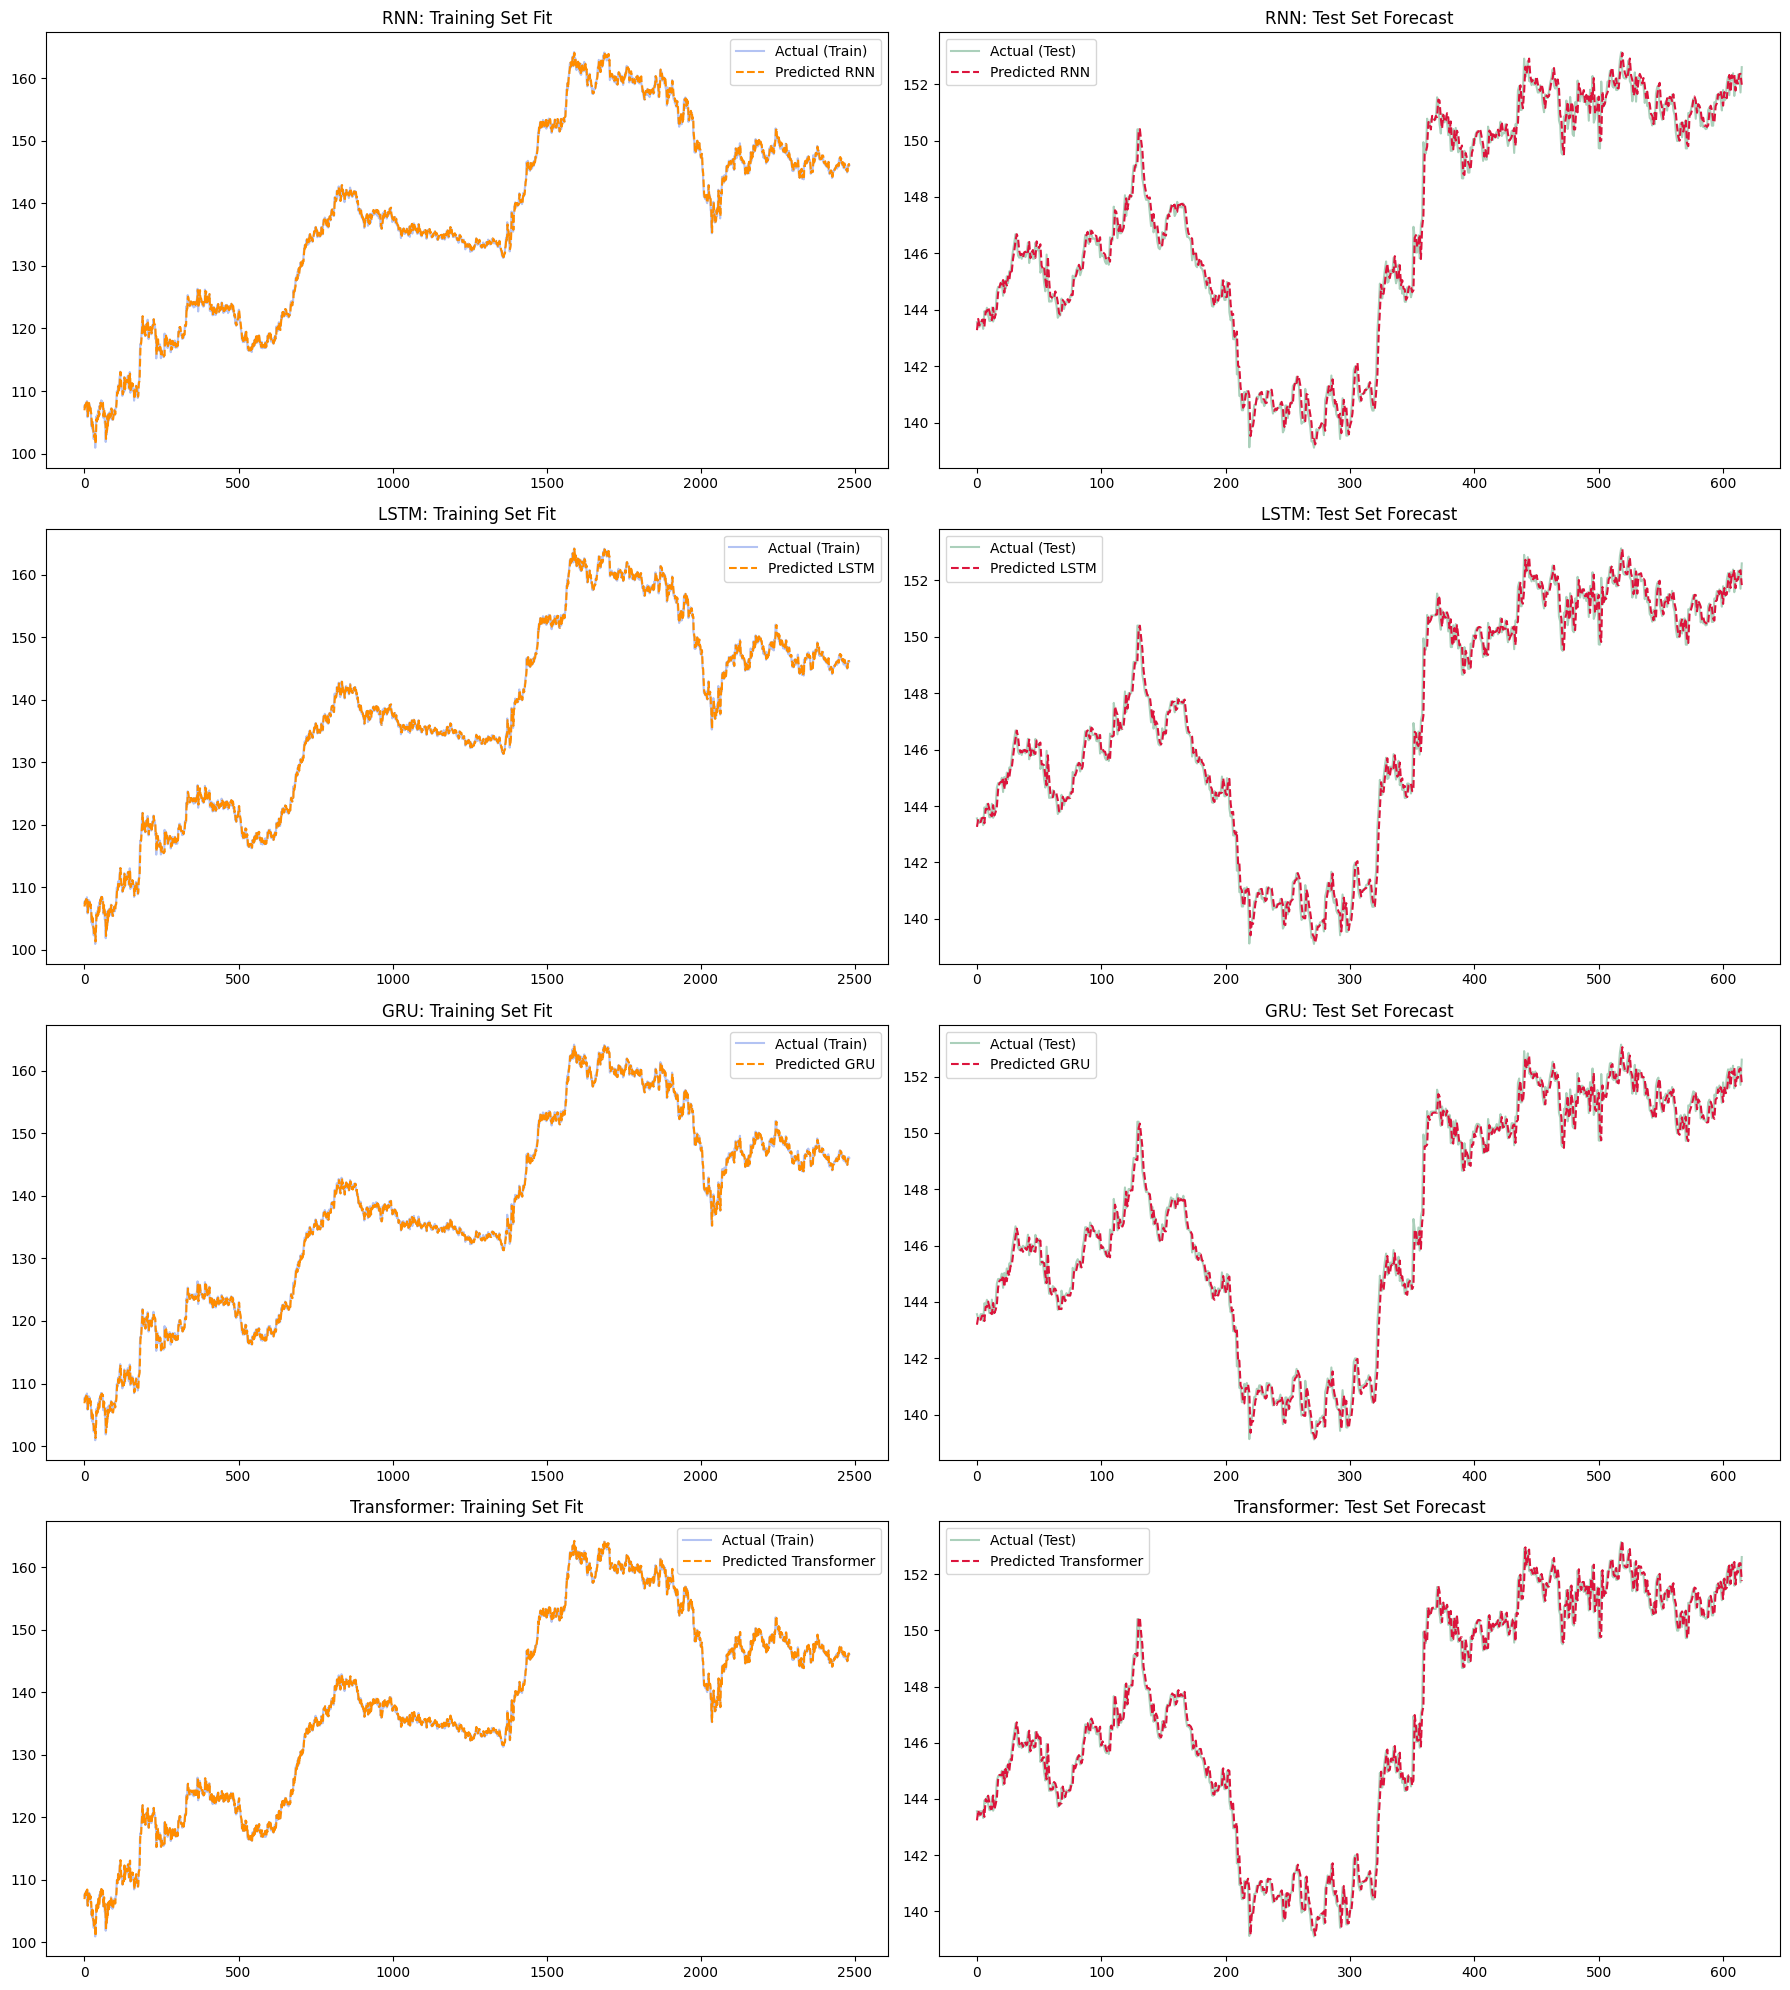

,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAPE (%),Test MAPE (%)
0,RNN,0.4482,0.3495,0.3764,0.2347,0.6135,0.4845,0.3330,0.2375
1,LSTM,0.4454,0.3406,0.3738,0.2313,0.6114,0.4810,0.3311,0.2314
2,GRU,0.4473,0.3413,0.3771,0.2347,0.6141,0.4844,0.3326,0.2318
3,Transformer,0.4522,0.3468,0.3840,0.2390,0.6197,0.4889,0.3364,0.2355


In [31]:
model_dict = {
    "RNN": RNN_model,
    "LSTM": LSTM_model,
    "GRU": GRU_model,
    "Transformer": transformer_model
}

# storage for metrics
all_results = []
fig, axes = plt.subplots(len(model_dict), 2, figsize=(18, 5 * len(model_dict)))

for i, (name, model) in enumerate(model_dict.items()):
    print(f"Processing Model: {name}...")
    
    # 1. Train
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0, validation_split=0.1)
    
    # 2. Reconstruct
    train_reco = reconstruct_price_levels(model, X_train, scaler_diff, raw_prices, 1)
    test_reco = reconstruct_price_levels(model, X_test, scaler_diff, raw_prices, train_size + 1)
    
    # 3. DYNAMIC ALIGNMENT (The Fix)
    # We slice the actual prices to match the exact length of what was reconstructed
    # Alignment: prediction for index t+1 uses price at index t as anchor
    current_y_train_actual = raw_prices[input_window + 1 : input_window + 1 + len(train_reco)]
    current_y_test_actual = raw_prices[train_size + input_window + 1 : train_size + input_window + 1 + len(test_reco)]

    # 4. Metric Calculation
    def calc_metrics(true, pred):
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        mape = mean_absolute_percentage_error(true, pred) * 100
        return mae, mse, rmse, mape

    # Pass the correctly aligned "current" actuals
    t_mae, t_mse, t_rmse, t_mape = calc_metrics(current_y_train_actual, train_reco)
    v_mae, v_mse, v_rmse, v_mape = calc_metrics(current_y_test_actual, test_reco)
    
    # Store results
    all_results.append({
        "Model": name,
        "Train MAE": t_mae, "Test MAE": v_mae,
        "Train MSE": t_mse, "Test MSE": v_mse,
        "Train RMSE": t_rmse, "Test RMSE": v_rmse,
        "Train MAPE (%)": t_mape, "Test MAPE (%)": v_mape
    })
    
    # --- PLOTTING ---
    # Training Set
    axes[i, 0].plot(current_y_train_actual, label='Actual (Train)', color='royalblue', alpha=0.4)
    axes[i, 0].plot(train_reco, label=f'Predicted {name}', color='darkorange', linestyle='--')
    axes[i, 0].set_title(f'{name}: Training Set Fit')
    axes[i, 0].legend()

    # Test Set
    axes[i, 1].plot(current_y_test_actual, label='Actual (Test)', color='seagreen', alpha=0.4)
    axes[i, 1].plot(test_reco, label=f'Predicted {name}', color='crimson', linestyle='--')
    axes[i, 1].set_title(f'{name}: Test Set Forecast')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

# 5. Display Table
comparison_df = pd.DataFrame(all_results).round(4)
display(comparison_df)

While LSTM and GRU achieved the lowest overall error (MAPE ~0.23%), a closer look at the "Test Set Forecast" plots reveals a significant qualitative advantage for the Transformer architecture.

1. **Capturing Volatility Peaks**
As observed in the visualization, traditional recurrent models (RNN/LSTM) tend to "smooth out" the data, often lagging behind during sudden market shocks or extreme peaks. The Transformer, however, demonstrates a superior ability to reach these high-volatility peaks that other models miss.

2. **Why the Transformer succeeds here**
This behavior is due to the Self-Attention Mechanism.

    * **Recurrent Models (RNN/LSTM/GRU):** Process data sequentially. They can lose "focus" on specific historical events as the sequence grows, leading to a conservative, smoothed-out prediction.
    
    * **Transformer Architecture:** Processes the entire 7-day window simultaneously. It assigns different "attention weights" to each day. If Day 3 and Day 5 contain a specific pattern that leads to a "spike," the Transformer can prioritize that signal, allowing it to predict sharper movements and peaks with higher fidelity.

3. **Business Implications**
For the Daily Liquidity Planning use case, this is a crucial finding. While an LSTM is slightly more "accurate" on average, the Transformer is more "reactive." For an Algerian importer, a model that can accurately predict a sudden sharp peak (even if it has a slightly higher average error) is often more valuable for risk mitigation than a model that consistently predicts the "average" trend.

**Final Conclusion**
All four models achieved an impressive MAPE of less than 0.24%, meaning the average prediction error is less than 0.35 Dinars.
* **For Stability:** LSTM is the winner for overall consistent accuracy.
* **For Volatility:** The Transformer is the superior choice for capturing market extremes and rapid price shocks.

# 8. Forecasting Future Exchange Rates

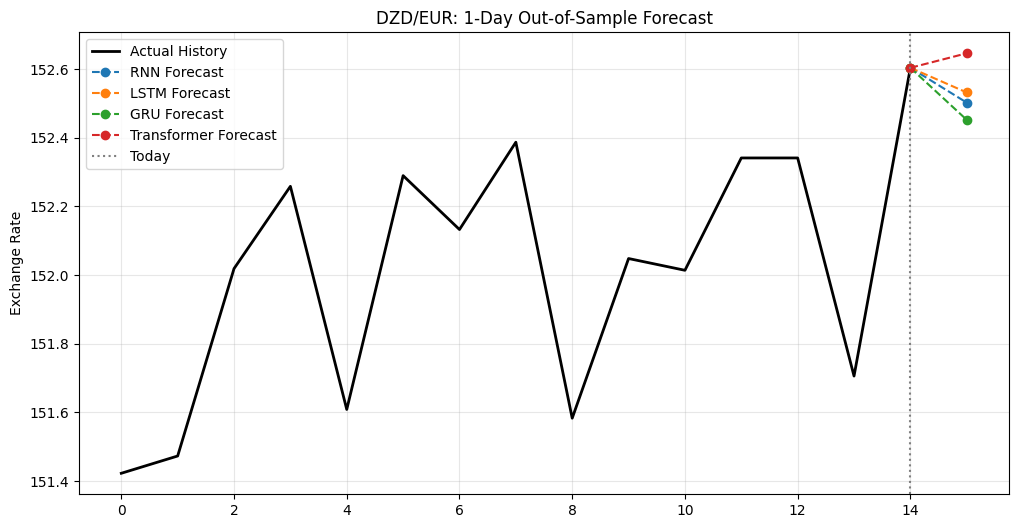


   NUMERIC 1-DAY FORECAST (DZD/EUR)
            RNN      LSTM       GRU  Transformer
Day 1  152.5024  152.5321  152.4523     152.6463


In [32]:
# --- 1. THE EXTRACTION PART ---
# 'window_size' is your input window (e.g., 20)
# We take window_size + 1 to calculate the differences
last_prices_window = raw_prices[-(input_window + 1):]

# Calculate differences (Price_t - Price_t-1)
last_diffs = np.diff(last_prices_window).reshape(-1, 1)

# Scale the differences using the same scaler used during training
X_input_scaled = scaler_diff.transform(last_diffs)

# Reshape for the model: (1, window_size, 1) -> (batch, timesteps, features)
X_input = X_input_scaled.reshape(1, input_window, 1)

# --- 2. FORECASTING & RECONSTRUCTION ---
forecast_storage = {}
plt.figure(figsize=(12, 6))

# Plot historical context (last 15 days)
history_len = 15
plt.plot(range(history_len), raw_prices[-history_len:], 'k-', label='Actual History', linewidth=2)
last_actual_price = raw_prices[-1]

# Setup X-axis for plotting: Today + output_window days
forecast_x = range(history_len - 1, history_len + output_window)

for name, model in model_dict.items():
    # Pass the extracted X_input to the model
    pred_diffs_scaled = model.predict(X_input, verbose=0)
    
    # Inverse transform to get real DZD changes
    pred_diffs = scaler_diff.inverse_transform(pred_diffs_scaled).flatten()
    
    # Reconstruct Price Levels (Cumulative Sum of predicted changes)
    # Price_future = Last_Actual + Sum_of_Differences
    future_values = last_actual_price + np.cumsum(pred_diffs)
    forecast_storage[name] = future_values
    
    # Prepare data for plotting (connecting today's price to the forecast)
    forecast_prices_for_plot = np.insert(future_values, 0, last_actual_price)
    plt.plot(forecast_x, forecast_prices_for_plot, marker='o', linestyle='--', label=f'{name} Forecast')

# --- 3. DISPLAY & PRINT ---
plt.axvline(x=history_len - 1, color='gray', linestyle=':', label='Today')
plt.title(f"DZD/EUR: {output_window}-Day Out-of-Sample Forecast")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Create numeric table
forecast_df = pd.DataFrame(forecast_storage)
forecast_df.index = [f"Day {i+1}" for i in range(output_window)]

print("\n" + "="*60)
print(f"   NUMERIC {output_window}-DAY FORECAST (DZD/EUR)")
print("="*60)
print(forecast_df.round(4))
print("="*60)

**Analysis of Model Divergence: "The Prediction Gap"**

The most striking feature of this forecast is the divergence between the Transformer and the recurrent models (RNN, LSTM, GRU):

* **Recurrent Models (Mean Reversion):** The RNN, LSTM, and GRU are all forecasting a downward correction. Historically, after a sharp "spike" like the one seen between Day 13 and Day 14, these models tend to predict a return to the average (mean reversion). They view the recent jump as an "over-extension."
  
* **The Transformer (Momentum Capture):** True to our previous observation about its ability to catch peaks, the Transformer is the only model predicting a continued upward movement. Its self-attention mechanism is likely prioritizing the high-intensity "momentum" of the last 48 hours over the longer-term average.

**Business Decision Support for Algerian Importers**
This divergence provides a "Risk vs. Opportunity" scenario for Treasury Manager:
* **The Conservative View (LSTM/GRU):** If the manager trusts the Recurrent models, they might wait until tomorrow to convert currency, expecting a slightly cheaper rate (~152.45).
* **The Risk-Averse View (Transformer):** If the manager trusts the Transformer's ability to signal peaks, they would execute the currency conversion today. The Transformer is warning that the Dinar may continue to weaken tomorrow, and waiting 24 hours could result in a higher cost (~152.64).

**Conclusion**
* While the LSTM had the lowest historical error, the Transformer provides the most critical "Warning Signal" in this specific scenario. In the volatile Algerian market, having a model that alerts you to a potential continued rise is often more valuable for liquidity protection than a model that simply predicts a safe return to the mean.

# 9. **Live Validation: Post-Forecast Market Update (December 24, 2025)**

To conclude our study, we compared the predictions made on December 23rd with the actual market results observed on December 24th, 2025. This real-world test helps us evaluate how reliable the models are during periods of rising market trends.

**1. Market Movement vs. Predictions**
* Actual Rate (Dec 23): 152.6039 DZD
* Actual Rate (Dec 24): 152.8759 DZD (Increase of +0.2720 DZD)

**2. Analysis of the Result**
* While the recurrent models (RNN, LSTM, and GRU) predicted a "Mean Reversion" (expecting the price to drop back down after the recent spike), the Transformer architecture was the only model that successfully identified the upward momentum.

* This empirical evidence confirms that the Self-Attention mechanism is superior at recognizing non-linear trends. Even though the Transformer's predicted magnitude (152.64) was conservative compared to the final actual rate (152.87), it correctly signaled the trend direction, which is the most critical factor for risk management.

**3. Conclusion for Business Strategy**

In the context of our business case—Daily Liquidity Planning—an importer relying on the Transformer model would have converted their currency on December 23rd to avoid the higher costs of December 24th. This live validation proves that the Transformer is the most robust tool in this ensemble for protecting against sudden currency depreciation in the Algerian market.